# 3 - Bài toán về thị giác máy tính 


## Something we must know computer vision libs in pytorch

* `torchvision` https://docs.pytorch.org/vision/stable/index.html
* `torchvision.dataset` - Nơi lấy bộ dữ liệu mẫu và những thứ hữu ích ở ni
* `torchvision.models` - Các anh tí anh tèo được sinh trước ăn học đầy đủ enough cho  việc giải quyết vấn đề cỏn con của chúng ta
* `torchvision.transforms` - đây là một đầu bếp đứng ra xào nấu data (image) để mô hình ML dễ ăn hơn 
* `torch.utils.data.Dataset` - Base dataset class for pytorch
* `torch.utils.data.DataLoader` - Tạo một iterable đi qua toàn bộ dữ liệu để dạo chơi

In [1]:
#import pytorch
import torch

from torch import nn

# Import torchvision
import torchvision

from torchvision import datasets

from torchvision import  transforms

from torchvision.transforms import ToTensor # Dùng để convert PIL image thành mảng num array dtype Tensor

import matplotlib.pyplot as plt

print(torch.__version__)
print(torchvision.__version__)

2.13.0+cu130
0.28.0+cu130


## 1. Khẩu chuẩn bị món ăn Cổ điển tôn trọng fashion MNIST

In [2]:
from torchvision import datasets

train_data = datasets.FashionMNIST(
    root="data", 
    train=True,
    download=True,
    transform=torchvision.transforms.ToTensor(),
    target_transform=None
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None
)



In [3]:
len(train_data), len(test_data)

(60000, 10000)

In [4]:
image, label = train_data[0]
image, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [5]:
class_name = train_data.classes
class_name

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [6]:
class_to_idx = train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [7]:
train_data.targets

tensor([9, 0, 0,  ..., 3, 0, 5])

In [8]:
#Chekc the shape

print(f'Image shape: {image.shape} -> [color chanels, height, width]')
print(f"Image label {class_name[label]}")

Image shape: torch.Size([1, 28, 28]) -> [color chanels, height, width]
Image label Ankle boot


### 1.2 Visualizing data

Image shape: torch.Size([1, 28, 28])


Text(0.5, 1.0, '9')

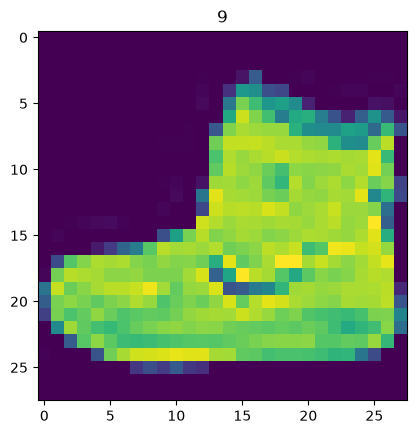

In [9]:
import matplotlib.pyplot as plt

image, label = train_data[0]
print(f'Image shape: {image.shape}')

plt.imshow(image.squeeze())

plt.title(label)

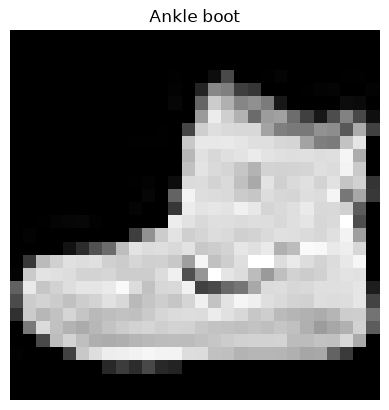

In [10]:
plt.imshow(image.squeeze(), cmap='gray')
plt.title(class_name[label]);
plt.axis(False);

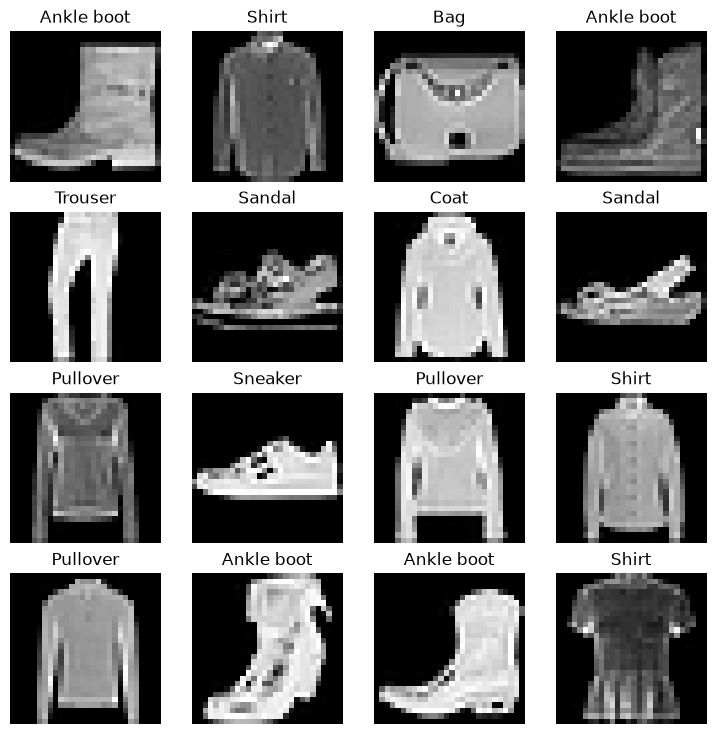

In [11]:
# Plot more images

torch.manual_seed(42)

fig = plt.figure(figsize=(9,9))
rows, cols = 4, 4

for i in range(1, rows*cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(class_name[label])
    plt.axis(False);

In [12]:
train_data, test_data

(Dataset FashionMNIST
     Number of datapoints: 60000
     Root location: data
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset FashionMNIST
     Number of datapoints: 10000
     Root location: data
     Split: Test
     StandardTransform
 Transform: ToTensor())

## 2. Chuẩn bị dữ liệu (DataLoader) 
Dữ liệu đang là pytorch Datasets
DataLoader sẽ chuyển chúng thành một interable python
1. Điều cần làm là thay vì nhét hết đống ảnh đó vô mô hình, thì cần chia batch ra 1 batch khoảng 32 ảnh
2. Việc này cần thiết để mô hình có thể cập nhật lại gradient cho mỗi epoch

In [13]:
from torch.utils.data import DataLoader

#Set up the batch size
BATCH_SIZE = 32
# Turn dataset into interable

train_dataloader = DataLoader(dataset= train_data, 
                            batch_size = BATCH_SIZE,
                            shuffle=True)
test_dataloader = DataLoader(dataset=test_data,
                            batch_size = BATCH_SIZE,
                            shuffle = False)

train_dataloader,test_dataloader


(<torch.utils.data.dataloader.DataLoader at 0x7f08d8abcc50>,
 <torch.utils.data.dataloader.DataLoader at 0x7f08d87cd4f0>)

In [14]:
# lets check out what I've created

print(f'DatalLoaders: {train_dataloader, test_dataloader}')
print(f'Length of train_dataloaders: {len(train_dataloader)} batches of {BATCH_SIZE}...')

print(f'Length of test_dataloaders: {len(test_dataloader)} batches of {BATCH_SIZE}')

DatalLoaders: (<torch.utils.data.dataloader.DataLoader object at 0x7f08d8abcc50>, <torch.utils.data.dataloader.DataLoader object at 0x7f08d87cd4f0>)
Length of train_dataloaders: 1875 batches of 32...
Length of test_dataloaders: 313 batches of 32


In [15]:
# Kiểm tra những gì có trong train_dataloader
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

In [16]:
len(train_features_batch)

32

Image size: torch.Size([1, 28, 28])
Label: 8, label size: torch.Size([])


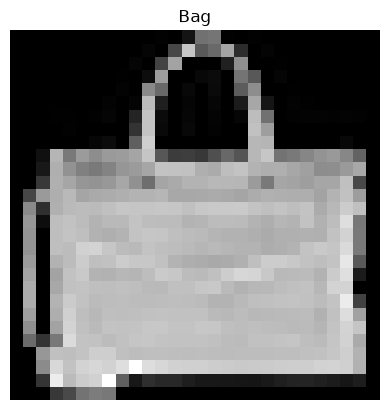

In [17]:
#torch.manual_seed(42)

random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()

img, label = train_features_batch[random_idx], train_labels_batch[random_idx]

plt.imshow(img.squeeze(), cmap='gray')
plt.title(class_name[label])
plt.axis(False)
print(f'Image size: {img.shape}')
print(f'Label: {label}, label size: {label.shape}')

## 3. Model 0 baseline model

In [18]:
flatten_model = nn.Flatten()

x = train_features_batch[0]
x.shape

#Flatten model
output = flatten_model(x)
print(f'shape before flatten: {x.shape} [color chanels, HEIGHT, WIDTH]')
print(f'shape after flatten: {output.shape} [color chanels,HEIGHT * WIDTH  ]')

shape before flatten: torch.Size([1, 28, 28]) [color chanels, HEIGHT, WIDTH]
shape after flatten: torch.Size([1, 784]) [color chanels,HEIGHT * WIDTH  ]


In [19]:
from torch import  nn

class FashionMNISTModelV0(nn.Module):
    def __init__(self, 
                input_shape: int,
                hidden_units: int,
                output_shape: int):
        super().__init__()

        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=output_shape),
        )
    def forward(self, x):
        return self.layer_stack(x)




In [20]:
len(class_name)

10

In [21]:
torch.manual_seed(42)

model_0 = FashionMNISTModelV0(
    input_shape = 28*28,
    hidden_units = 10,
    output_shape = len(class_name)
).to("cpu")

model_0


FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [22]:
dummy_x = torch.rand([1,1,28,28])

model_0(dummy_x)

tensor([[-0.0315,  0.3171,  0.0531, -0.2525,  0.5959,  0.2112,  0.3233,  0.2694,
         -0.1004,  0.0157]], grad_fn=<AddmmBackward0>)

In [23]:
model_0.state_dict()

OrderedDict([('layer_stack.1.weight',
              tensor([[ 0.0273,  0.0296, -0.0084,  ..., -0.0142,  0.0093,  0.0135],
                      [-0.0188, -0.0354,  0.0187,  ..., -0.0106, -0.0001,  0.0115],
                      [-0.0008,  0.0017,  0.0045,  ..., -0.0127, -0.0188,  0.0059],
                      ...,
                      [-0.0116,  0.0273, -0.0344,  ...,  0.0176,  0.0283, -0.0011],
                      [-0.0230,  0.0257,  0.0291,  ..., -0.0187, -0.0087,  0.0001],
                      [ 0.0176, -0.0147,  0.0053,  ..., -0.0336, -0.0221,  0.0205]])),
             ('layer_stack.1.bias',
              tensor([-0.0093,  0.0283, -0.0033,  0.0255,  0.0017,  0.0037, -0.0302, -0.0123,
                       0.0018,  0.0163])),
             ('layer_stack.2.weight',
              tensor([[ 0.0614, -0.0687,  0.0021,  0.2718,  0.2109,  0.1079, -0.2279, -0.1063,
                        0.2019,  0.2847],
                      [-0.1495,  0.1344, -0.0740,  0.2006, -0.0475, -0.2514, -0.

### 3.1 Tôn trọng cổ điển khởi tạo loss fn and optimizer

* Loss func with multi classification using CrossentropyLoss(),
* Optimizer SGD
* Accuracy đo sự chính xác nhe

In [24]:
import requests
from pathlib import Path 

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

helper_functions.py already exists, skipping download


In [25]:
#Import Accuracy metric

from helper_functions import  accuracy_fn

#Set up loss and optimizer

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

### 3.2 Đồng hố đếm ngược nè Shizuka
* How fast model run
* How the model perform

In [26]:
from timeit import  default_timer as timer
def print_time_train(start: float,
                    end: float,
                    device: torch.device=None):
    total_time = end - start
    print(f'Train time on {device}: total time: {total_time:.3f} seconds')
    return total_time

In [27]:
start_time = timer()


end_time = timer()

print_time_train(start=start_time, end=end_time, device="cpu")

Train time on cpu: total time: 0.000 seconds


2.8013999326503836e-05

### 3.3 Training loop

In [28]:
train_dataloader

In [29]:
from tqdm.auto import tqdm  

torch.manual_seed(42)

train_time_start_on_cpu = timer()

epochs = 3

for epoch in tqdm(range(epochs)):
    print(f'Epoch {epoch} \n--------')

    ### Training
    train_loss = 0

    # Thêm 1 vòng lặp nữa để đi qua training batches 
    for batch,(X,y) in enumerate(train_dataloader):
        model_0.train()

        y_pred = model_0(X)

        loss = loss_fn(y_pred, y)
        train_loss += loss
        
        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        if batch % 400 == 0:
            print(f'Look at batch: {batch * len(X)} / {len(train_dataloader.dataset)} samples')

    # Device total train loss by length of train dataloader
    train_loss /= len(train_dataloader)

    ### testing
    test_loss, test_acc = 0,0
    model_0.eval()
    with torch.inference_mode():
        for X_test, y_test in test_dataloader:

            test_pred = model_0(X_test)

            test_loss += loss_fn(test_pred, y_test)

            test_acc += accuracy_fn(y_true=y_test, y_pred=test_pred.argmax(dim=1))
            
        test_loss /= len(test_dataloader)

        test_acc /= len(test_dataloader)
    print(f'\nTrain Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}')


train_time_end_on_cpu = timer()

total_train_time_model_0 = print_time_train(start=train_time_start_on_cpu,
                                            end=train_time_end_on_cpu, 
                                            device=str(next(model_0.parameters()).device))

/home/tuana/Projects/Code/ML/tf/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
  0%|          | 0/3 [00:00<?, ?it/s]

Epoch 0 
--------
Look at batch: 0 / 60000 samples
Look at batch: 12800 / 60000 samples
Look at batch: 25600 / 60000 samples
Look at batch: 38400 / 60000 samples
Look at batch: 51200 / 60000 samples


 33%|███▎      | 1/3 [00:08<00:16,  8.17s/it]


Train Loss: 0.5904 | Test Loss: 0.5095 | Test Accuracy: 82.0387
Epoch 1 
--------
Look at batch: 0 / 60000 samples
Look at batch: 12800 / 60000 samples
Look at batch: 25600 / 60000 samples
Look at batch: 38400 / 60000 samples
Look at batch: 51200 / 60000 samples


 67%|██████▋   | 2/3 [00:16<00:08,  8.14s/it]


Train Loss: 0.4763 | Test Loss: 0.4799 | Test Accuracy: 83.1969
Epoch 2 
--------
Look at batch: 0 / 60000 samples
Look at batch: 12800 / 60000 samples
Look at batch: 25600 / 60000 samples
Look at batch: 38400 / 60000 samples
Look at batch: 51200 / 60000 samples


100%|██████████| 3/3 [00:23<00:00,  7.98s/it]


Train Loss: 0.4550 | Test Loss: 0.4766 | Test Accuracy: 83.4265
Train time on cpu: total time: 23.939 seconds


## 4 Make prediction and get model 0 result


In [30]:
torch.manual_seed(42)
def eval_model(model: torch.nn.Module,
                data_loader:torch.utils.data.DataLoader,
                loss_fn: torch.nn.Module,
                accuracy_fn):
    loss, acc = 0,0
    model.eval()
    with torch.inference_mode():
        for X,y in data_loader:
            
            y_pred = model(X)

            loss += loss_fn(y_pred,y)
            acc += accuracy_fn(y_true = y, y_pred= y_pred.argmax(dim=1))

        loss /= len(data_loader)
        acc /= len(data_loader)
    
    return {'model_name': model.__class__.__name__, 
            'model_loss': loss.item(), 
            'model_acc': acc}

model_0_results = eval_model(model=model_0,
                            data_loader=test_dataloader,
                            loss_fn=loss_fn,
                            accuracy_fn=accuracy_fn)
model_0_results
            

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.47663894295692444,
 'model_acc': 83.42651757188499}

## 5. Chơi với gpu time

In [31]:
!nvidia-smi

Thu Aug 20 01:36:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 610.43.03              KMD Version: 610.43.03     CUDA UMD Version: 13.3     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1650 ...    Off |   00000000:02:00.0 Off |                  N/A |
| N/A   49C    P8              1W /   35W |       8MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [32]:
torch.cuda.is_available()

True

In [33]:
import torch 
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## 6. Model 1: Một mô hình tốt hơn với công cụ non-linear


In [34]:
class FashionMNISTModelV1(nn.Module):
    def __init__(self,
                input_shape: int,
                hidden_units: int,
                output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_shape),
            nn.ReLU()
      )
    def forward(self, x: torch.Tensor):
        return self.layer_stack(x)
    


In [35]:
# Khởi tạo một mô hình
torch.manual_seed(42)

torch.cuda.manual_seed(42)

model_1 = FashionMNISTModelV1(input_shape=28*28, hidden_units=10, output_shape=len(class_name)).to(device)

next(model_1.parameters()).device

device(type='cuda', index=0)

In [36]:
print(model_1)
print(next(model_1.parameters()).device)

print("Model weight:")
print(model_1.layer_stack[1].weight[:2])

print("Optimizer parameters:")
print(len(optimizer.param_groups[0]["params"]))

FashionMNISTModelV1(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): ReLU()
    (3): Linear(in_features=10, out_features=10, bias=True)
    (4): ReLU()
  )
)
cuda:0
Model weight:
tensor([[ 0.0273,  0.0296, -0.0084,  ..., -0.0142,  0.0093,  0.0135],
        [-0.0188, -0.0354,  0.0187,  ..., -0.0106, -0.0001,  0.0115]],
       device='cuda:0', grad_fn=<SliceBackward0>)
Optimizer parameters:
4


### 6.1 Loss và optimizer

In [37]:
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.1)



### 6.2 Nấu quả func cho 2 quá trình train và test lets gooooo

* training loop - `train_step()`
* testing loop - `test_step()`

In [38]:
def train_step(model: torch.nn.Module,
                data_loader: torch.utils.data.DataLoader,
                loss_fn: torch.nn.Module,
                optimizer: torch.optim.Optimizer,
                accuracy_fn,
                device: torch.device = device):
    
    ### Training
    train_loss, train_acc = 0,0
    model.train()

    # Thêm 1 vòng lặp nữa để đi qua training batches 
    for batch,(X,y) in enumerate(data_loader):
        X,y = X.to(device), y.to(device)        

        y_pred = model(X)

        loss = loss_fn(y_pred, y)
        
        train_loss += loss
        train_acc += accuracy_fn(y_true=y,
                                 y_pred=y_pred.argmax(dim=1))
        optimizer.zero_grad()

        loss.backward()

        optimizer.step()
    # Device total train loss by length of train dataloader
    train_loss /= len(data_loader)

    train_acc /= len(data_loader)
    
    print(f'Train loss: {train_loss:.5f} | Train acc: {train_acc:.2f}%')

In [39]:
def test_step(model: torch.nn.Module,
            data_loader: torch.utils.data.DataLoader,
            loss_fn: torch.nn.Module,
            accuracy_fn,
            device: torch.device = device):

### testing
    test_loss, test_acc = 0,0
    model.eval()
    with torch.inference_mode():
        for X_test, y_test in data_loader:
            X_test, y_test = X_test.to(device), y_test.to(device)

            
            test_pred = model(X_test)

            test_loss += loss_fn(test_pred, y_test)

            test_acc += accuracy_fn(y_true=y_test, y_pred=test_pred.argmax(dim=1))
            
        test_loss /= len(data_loader)

        test_acc /= len(data_loader)
    print(f'\nTest Loss: {test_loss:.5f} | Test Accuracy: {test_acc:.2f}%')



In [40]:
torch.manual_seed(42)

from timeit import default_timer as timer
train_time_start_on_gpu = timer()

epochs = 3

for epoch in tqdm(range(epochs)):
    print(f'Epoch: {epoch}\n-----------')
    train_step(model=model_1,
                data_loader=train_dataloader, 
                loss_fn=loss_fn,
                optimizer=optimizer,
                accuracy_fn=accuracy_fn,
                device=device)
    test_step(model=model_1, 
            data_loader=test_dataloader, 
            loss_fn=loss_fn, 
            accuracy_fn=accuracy_fn, 
            device=device)

train_time_end_on_gpu = timer()

total_train_time_model_1 = print_time_train(start=train_time_start_on_gpu, end=train_time_end_on_gpu, device=device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-----------
Train loss: 1.09199 | Train acc: 61.34%


 33%|███▎      | 1/3 [00:09<00:18,  9.38s/it]


Test Loss: 0.95636 | Test Accuracy: 65.00%
Epoch: 1
-----------
Train loss: 0.78101 | Train acc: 71.93%


 67%|██████▋   | 2/3 [00:18<00:09,  9.14s/it]


Test Loss: 0.72227 | Test Accuracy: 73.91%
Epoch: 2
-----------
Train loss: 0.67027 | Train acc: 75.94%


100%|██████████| 3/3 [00:27<00:00,  9.08s/it]


Test Loss: 0.68500 | Test Accuracy: 75.02%
Train time on cuda: total time: 27.243 seconds


> **Lưu ý:** Thời gian huấn luyện trên CUDA so với CPU phụ thuộc rất nhiều vào chất lượng của CPU/GPU mà bạn đang sử dụng. Hãy đọc tiếp để biết thêm chi tiết.

> **Câu hỏi:** "Tôi đã sử dụng GPU nhưng mô hình không huấn luyện nhanh hơn, tại sao lại như vậy?"
>
> **Trả lời:** Một lý do có thể là do tập dữ liệu và mô hình của bạn quá nhỏ (giống như tập dữ liệu và mô hình mà chúng ta đang sử dụng); khi đó, lợi ích của việc dùng GPU lại bị triệt tiêu bởi thời gian thực tế cần thiết để chuyển dữ liệu sang đó.
>
> Có một điểm nghẽn nhỏ trong quá trình sao chép dữ liệu từ bộ nhớ CPU (mặc định) sang bộ nhớ GPU.
>
> Vì vậy, đối với các mô hình và tập dữ liệu nhỏ, CPU thực sự có thể là nơi tối ưu để thực hiện tính toán.
>
> Tuy nhiên, với các tập dữ liệu và mô hình lớn hơn, tốc độ tính toán mà GPU mang lại thường vượt xa chi phí thời gian để chuyển dữ liệu sang đó.
>
> Dù vậy, điều này phụ thuộc phần lớn vào phần cứng bạn đang sử dụng. Qua quá trình thực hành, bạn sẽ dần quen với việc xác định đâu là nơi tốt nhất để huấn luyện mô hình của mình.

In [41]:
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.47663894295692444,
 'model_acc': 83.42651757188499}

In [42]:
total_train_time_model_0

23.939266356999724

In [43]:
torch.manual_seed(42)
def eval_model(model: torch.nn.Module,
                data_loader:torch.utils.data.DataLoader,
                loss_fn: torch.nn.Module,
                accuracy_fn,
                device=device):
    loss, acc = 0,0
    model.eval()
    with torch.inference_mode():
        for X,y in data_loader:
            X,y = X.to(device), y.to(device)
            y_pred = model(X)

            loss += loss_fn(y_pred,y)
            acc += accuracy_fn(y_true = y, y_pred= y_pred.argmax(dim=1))

        loss /= len(data_loader)
        acc /= len(data_loader)
    
    return {'model_name': model.__class__.__name__, 
            'model_loss': loss.item(), 
            'model_acc': acc}


            

In [44]:
model_1_results = eval_model(model=model_1,
                            data_loader=test_dataloader, 
                            loss_fn=loss_fn, 
                            accuracy_fn=accuracy_fn,
                            device=device)

In [45]:
model_1_results

{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.6850008964538574,
 'model_acc': 75.01996805111821}

## 7 Xây dựng model dùng conv1d gô gô gô convolution (CNN)
* https://viblo.asia/p/deep-learning-tim-hieu-ve-mang-tich-chap-cnn-maGK73bOKj2
* `Convolution in CNN`
* `Pool in CNN` https://youtu.be/lzmqzNFfJXA?si=Agmdgfe-y48wN7at
* https://poloclub.github.io/cnn-explainer/

In [115]:
class FashionMNISTModelV2(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,out_channels= hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1,padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*7*7, out_features=output_shape)
        )
    def forward(self, x):
        x = self.conv_block_1(x)
        #print(f'Out put shape of conv_block_1: {x.shape}')
        x = self.conv_block_2(x)
        #print(f'Out put shape of conv_block_2: {x.shape}')
        x = self.classifier(x)

        #print(f'Out put shape of classifier: {x.shape}')
        return x

In [116]:
torch.manual_seed(42)
model_2 = FashionMNISTModelV2(input_shape=1, hidden_units=10, output_shape=len(class_name)).to(device)

In [100]:
rand_img_tensor = torch.randn(size=(1,28,28))
rand_img_tensor.shape

torch.Size([1, 28, 28])

In [110]:
model_2(rand_img_tensor.unsqueeze(0).to(device))

Out put shape of conv_block_1: torch.Size([1, 10, 14, 14])
Out put shape of conv_block_2: torch.Size([1, 10, 7, 7])
Out put shape of classifier: torch.Size([1, 10])


tensor([[ 0.0402, -0.0870,  0.0767, -0.0430,  0.0317,  0.0221,  0.0063, -0.0002,
          0.0030, -0.0256]], device='cuda:0', grad_fn=<AddmmBackward0>)

#### Tips and trick tìm shape cuối cùng

In [ ]:
model_2(rand_img_tensor.unsqueeze(0).to(device))

Out put shape of conv_block_1: torch.Size([10, 14, 14])
Out put shape of conv_block_2: torch.Size([10, 7, 7])


RuntimeError: mat1 and mat2 shapes cannot be multiplied (10x49 and 10x10)

### 7.1 Tìm hiểu về `nn.Conv2d` 
Tìm đầu ra Calculate the shape  https://youtu.be/VSgNlE414qM?si=D0q_bqd3ZYwqlolg 

In [57]:
torch.manual_seed(42)


images = torch.randn(size=(32,3,64,64))
test_image = images[0]
print(f'Image bacth shape: {images.shape}')
print(f'Single image shape: {test_image.shape}')
print(f'Test Image : {test_image}')


Image bacth shape: torch.Size([32, 3, 64, 64])
Single image shape: torch.Size([3, 64, 64])
Test Image : tensor([[[ 1.9269,  1.4873,  0.9007,  ...,  1.8446, -1.1845,  1.3835],
         [ 1.4451,  0.8564,  2.2181,  ...,  0.3399,  0.7200,  0.4114],
         [ 1.9312,  1.0119, -1.4364,  ..., -0.5558,  0.7043,  0.7099],
         ...,
         [-0.5610, -0.4830,  0.4770,  ..., -0.2713, -0.9537, -0.6737],
         [ 0.3076, -0.1277,  0.0366,  ..., -2.0060,  0.2824, -0.8111],
         [-1.5486,  0.0485, -0.7712,  ..., -0.1403,  0.9416, -0.0118]],

        [[-0.5197,  1.8524,  1.8365,  ...,  0.8935, -1.5114, -0.8515],
         [ 2.0818,  1.0677, -1.4277,  ...,  1.6612, -2.6223, -0.4319],
         [-0.1010, -0.4388, -1.9775,  ...,  0.2106,  0.2536, -0.7318],
         ...,
         [ 0.2779,  0.7342, -0.3736,  ..., -0.4601,  0.1815,  0.1850],
         [ 0.7205, -0.2833,  0.0937,  ..., -0.1002, -2.3609,  2.2465],
         [-1.3242, -0.1973,  0.2920,  ...,  0.5409,  0.6940,  1.8563]],

        [[-0

In [60]:
test_image.shape

torch.Size([3, 64, 64])

In [71]:

torch.manual_seed(42)
conv_layer = nn.Conv2d(in_channels=3, out_channels=10, kernel_size=(3,3), stride=1, padding=1)

conv_output = conv_layer(test_image)
conv_output.shape

torch.Size([10, 64, 64])

### 7.2 Nhờn với `nn.MaxPool2D`

In [76]:
print(f'Test image original shape: {test_image.shape}')
print(f'Test image with unsqueezed dimension: {test_image.unsqueeze(0).shape}')


max_pool2D_layer  = nn.MaxPool2d(kernel_size=2)

test_image_through_conv = conv_layer(test_image.unsqueeze(dim=0))

print(f'Shape after pass through conv layer {test_image_through_conv.shape}')

test_image_through_max_pool = max_pool2D_layer(test_image_through_conv)


print(f'Shape after pass through conv and max pool layer {test_image_through_max_pool.shape}')


Test image original shape: torch.Size([3, 64, 64])
Test image with unsqueezed dimension: torch.Size([1, 3, 64, 64])
Shape after pass through conv layer torch.Size([1, 10, 64, 64])
Shape after pass through conv and max pool layer torch.Size([1, 10, 32, 32])


### 7.3 Loss and optimzier

In [117]:
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(params=model_2.parameters(), lr=0.1)



### 7.4 Training and testing

In [118]:
torch.manual_seed(42)

torch.cuda.manual_seed(42)

epochs = 3

from timeit import default_timer as timer

time_start_model_2 = timer()

for epoch in tqdm(range(epochs)):
    print(f'Epoch: {epoch} \n---------------')

    train_step(model=model_2, data_loader=train_dataloader, loss_fn=loss_fn, optimizer=optimizer, accuracy_fn=accuracy_fn, device=device)

    test_step(model=model_2, data_loader=test_dataloader, loss_fn=loss_fn, accuracy_fn=accuracy_fn, device=device)
time_end_model_2 = timer()

total_train_time = print_time_train(start=time_start_model_2, end=time_end_model_2,device=device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0 
---------------
Train loss: 0.59773 | Train acc: 78.43%


 33%|███▎      | 1/3 [00:09<00:19,  9.90s/it]


Test Loss: 0.39510 | Test Accuracy: 85.87%
Epoch: 1 
---------------
Train loss: 0.35651 | Train acc: 87.24%


 67%|██████▋   | 2/3 [00:20<00:10, 10.19s/it]


Test Loss: 0.35218 | Test Accuracy: 87.11%
Epoch: 2 
---------------
Train loss: 0.31916 | Train acc: 88.50%


100%|██████████| 3/3 [00:31<00:00, 10.37s/it]


Test Loss: 0.32242 | Test Accuracy: 88.26%
Train time on cuda: total time: 31.115 seconds


### 7.5 Hái quả 

In [144]:
model_2_results = eval_model(model=model_2,data_loader=test_dataloader,loss_fn=loss_fn,accuracy_fn=accuracy_fn, device=device)
model_2_results

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.32242271304130554,
 'model_acc': 88.25878594249201}

## 8 `(Optional)` so sánh kết quả giữa các model từ đơn giản đến phức tạp

In [146]:
import pandas as pd

compare_results = pd.DataFrame([model_0_results, model_1_results, model_2_results])

compare_results

,model_name,model_loss,model_acc
0,FashionMNISTModelV0,0.476639,83.426518
1,FashionMNISTModelV1,0.685001,75.019968
2,FashionMNISTModelV2,0.322423,88.258786


In [147]:
compare_results["training_time"] = [total_train_time_model_0, total_train_time_model_1,total_train_time]

compare_results

,model_name,model_loss,model_acc,training_time
0,FashionMNISTModelV0,0.476639,83.426518,23.939266
1,FashionMNISTModelV1,0.685001,75.019968,27.243326
2,FashionMNISTModelV2,0.322423,88.258786,31.115174


Text(0, 0.5, 'model')

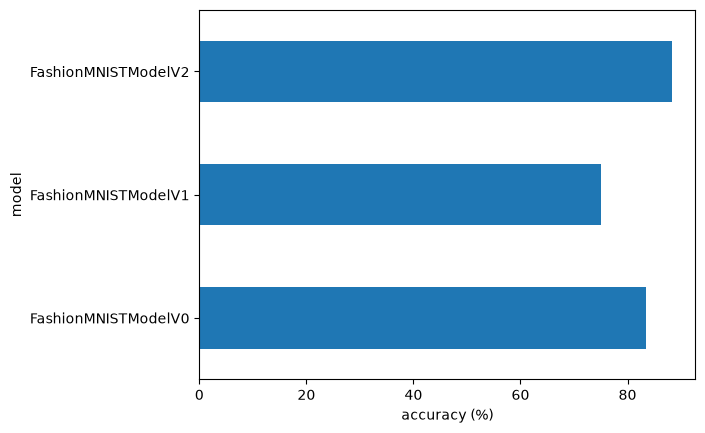

In [148]:
compare_results.set_index('model_name')['model_acc'].plot(kind='barh')
plt.xlabel('accuracy (%)')
plt.ylabel('model')

In [149]:
def make_predictions(model: torch.nn.Module, data: list, device: torch.device = device):
    
    pred_probs = []
    model.eval()
    with torch.inference_mode():
        for sample in data:
            sample = torch.unsqueeze(sample, dim=0).to(device)

            pred_logit = model(sample)

            pred_prob = torch.softmax(pred_logit.squeeze(), dim=0)

            pred_probs.append(pred_prob.cpu())

    return torch.stack(pred_probs)




In [150]:
test_data

Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [155]:
import random

# random.seed(42)

test_samples=[]
test_labels= []

for sample, label in random.sample(list(test_data), k =9):
    test_samples.append(sample)
    test_labels.append(label)

test_samples[0].shape

torch.Size([1, 28, 28])

In [156]:
pred_probs = make_predictions(model=model_2, data=test_samples)

pred_probs[:2]

tensor([[2.7665e-01, 6.0371e-05, 3.7591e-04, 2.9044e-02, 6.9918e-04, 1.3318e-06,
         6.9289e-01, 7.5613e-06, 2.6792e-04, 3.0170e-06],
        [6.7150e-05, 3.7125e-06, 7.3735e-01, 6.6980e-05, 2.6146e-01, 4.7948e-07,
         1.0466e-03, 1.0447e-07, 5.9705e-06, 3.8045e-07]])

In [157]:
pred_classes = pred_probs.argmax(dim=1)
pred_classes

tensor([6, 2, 5, 8, 5, 8, 9, 8, 5])

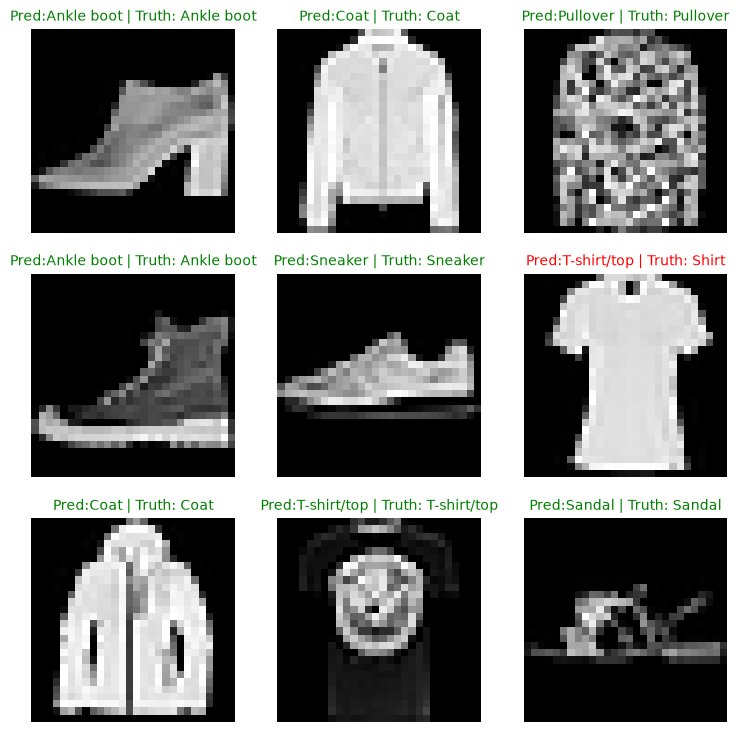

In [154]:
plt.figure(figsize=(9,9))

nrows = 3
ncols = 3

for i, sample in enumerate(test_samples):
    plt.subplot(nrows, ncols, i + 1)
    plt.imshow(sample.squeeze(), cmap='gray')

    pred_label = class_name[pred_classes[i]]

    truth_label = class_name[test_labels[i]]

    title_text  = f'Pred:{pred_label} | Truth: {truth_label}'

    if pred_label == truth_label:
        plt.title(title_text, fontsize=10, c="g")
    else:
        plt.title(title_text, fontsize=10, c='r')
    plt.axis(False)